# DU-04 — Analyze Relationships Between Datasets

**Fase:** Data Understanding  
**Proyecto:** Healthcare AI Billing Auditor  
**Metodología:** ASUM-DM  

Análisis de las relaciones entre los cinco datasets para definir la estrategia de JOIN que permitirá construir el Master Dataset.

---
## 1. Configuración y Carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 30)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_RAW_PATH = Path('../data/raw')

pacientes = pd.read_csv(DATA_RAW_PATH / '01_pacientes.csv')
atenciones = pd.read_csv(DATA_RAW_PATH / '02_atenciones.csv')
historia_clinica = pd.read_csv(DATA_RAW_PATH / '03_historia_clinica_detalle.csv')
prefactura = pd.read_csv(DATA_RAW_PATH / '04_prefactura.csv')
cruce_validacion = pd.read_csv(DATA_RAW_PATH / '05_cruce_validacion.csv')

print('Datasets cargados:')
for name, df in [('pacientes', pacientes), ('atenciones', atenciones),
                  ('historia_clinica', historia_clinica), ('prefactura', prefactura),
                  ('cruce_validacion', cruce_validacion)]:
    print(f'  {name}: {df.shape[0]:,} registros, {df.shape[1]} columnas')

Datasets cargados:
  pacientes: 300 registros, 7 columnas
  atenciones: 1,200 registros, 9 columnas
  historia_clinica: 3,056 registros, 9 columnas
  prefactura: 2,974 registros, 10 columnas
  cruce_validacion: 3,126 registros, 8 columnas


---
## 2. Identificación de Identificadores Comunes

In [2]:
# Definición de relaciones según la arquitectura de datos (AA-02)
relationships = [
    {
        'parent': 'pacientes',
        'child': 'atenciones',
        'pk': 'id_paciente',
        'fk': 'id_paciente',
        'expected_card': '1:N',
    },
    {
        'parent': 'atenciones',
        'child': 'historia_clinica',
        'pk': 'id_atencion',
        'fk': 'id_atencion',
        'expected_card': '1:N',
    },
    {
        'parent': 'atenciones',
        'child': 'prefactura',
        'pk': 'id_atencion',
        'fk': 'id_atencion',
        'expected_card': '1:N',
    },
    {
        'parent': 'atenciones',
        'child': 'cruce_validacion',
        'pk': 'id_atencion',
        'fk': 'id_atencion',
        'expected_card': '1:N',
    },
    {
        'parent': 'historia_clinica',
        'child': 'cruce_validacion',
        'pk': 'id_detalle',
        'fk': 'id_detalle_hc',
        'expected_card': '1:N',
    },
    {
        'parent': 'prefactura',
        'child': 'cruce_validacion',
        'pk': 'id_prefactura',
        'fk': 'id_prefactura',
        'expected_card': '1:N',
    },
]

datasets_dict = {
    'pacientes': pacientes,
    'atenciones': atenciones,
    'historia_clinica': historia_clinica,
    'prefactura': prefactura,
    'cruce_validacion': cruce_validacion,
}

print('=== IDENTIFICADORES COMUNES ===\n')
print(f'{"Relación":<45} {"PK":<18} {"FK":<18} {"Cardinalidad"}')
print('-' * 100)
for rel in relationships:
    rel_name = f'{rel["parent"]} → {rel["child"]}'
    print(f'{rel_name:<45} {rel["pk"]:<18} {rel["fk"]:<18} {rel["expected_card"]}')

=== IDENTIFICADORES COMUNES ===

Relación                                      PK                 FK                 Cardinalidad
----------------------------------------------------------------------------------------------------
pacientes → atenciones                        id_paciente        id_paciente        1:N
atenciones → historia_clinica                 id_atencion        id_atencion        1:N
atenciones → prefactura                       id_atencion        id_atencion        1:N
atenciones → cruce_validacion                 id_atencion        id_atencion        1:N
historia_clinica → cruce_validacion           id_detalle         id_detalle_hc      1:N
prefactura → cruce_validacion                 id_prefactura      id_prefactura      1:N


---
## 3. Validación de Integridad Referencial

In [3]:
print('=== INTEGRIDAD REFERENCIAL ===\n')

integrity_results = []
for rel in relationships:
    parent_df = datasets_dict[rel['parent']]
    child_df = datasets_dict[rel['child']]
    pk_col = rel['pk']
    fk_col = rel['fk']
    
    parent_keys = set(parent_df[pk_col].dropna())
    child_keys = set(child_df[fk_col].dropna())
    
    orphans = child_keys - parent_keys
    unused_parents = parent_keys - child_keys
    
    total_child = child_df[fk_col].notna().sum()
    orphan_count = child_df[fk_col].dropna().isin(list(orphans)).sum() if orphans else 0
    
    integrity_results.append({
        'Relación': f'{rel["parent"]}.{pk_col} → {rel["child"]}.{fk_col}',
        'Registros hijo': total_child,
        'Huérfanos': orphan_count,
        'Padres sin hijos': len(unused_parents),
        'Integridad': '✅' if orphan_count == 0 else '⚠️',
    })

integrity_df = pd.DataFrame(integrity_results)
integrity_df

=== INTEGRIDAD REFERENCIAL ===



,Relación,Registros hijo,Huérfanos,Padres sin hijos,Integridad
0,pacientes.id_paciente → atenciones.id_paciente,1200,0,7,✅
1,atenciones.id_atencion → historia_clinica.id_a...,3056,0,0,✅
2,atenciones.id_atencion → prefactura.id_atencion,2974,0,0,✅
3,atenciones.id_atencion → cruce_validacion.id_a...,3126,0,0,✅
4,historia_clinica.id_detalle → cruce_validacion...,3056,0,0,✅
5,prefactura.id_prefactura → cruce_validacion.id...,2974,0,0,✅


---
## 4. Análisis de Cardinalidad

In [4]:
print('=== CARDINALIDAD POR RELACIÓN ===\n')

cardinality_results = []
for rel in relationships:
    parent_df = datasets_dict[rel['parent']]
    child_df = datasets_dict[rel['child']]
    pk_col = rel['pk']
    fk_col = rel['fk']
    
    # Count children per parent
    children_per_parent = child_df[fk_col].dropna().value_counts()
    
    cardinality_results.append({
        'Relación': f'{rel["parent"]} → {rel["child"]}',
        'FK': fk_col,
        'Cardinalidad': rel['expected_card'],
        'Min hijos': children_per_parent.min() if len(children_per_parent) > 0 else 0,
        'Max hijos': children_per_parent.max() if len(children_per_parent) > 0 else 0,
        'Promedio hijos': round(children_per_parent.mean(), 2) if len(children_per_parent) > 0 else 0,
        'Mediana hijos': children_per_parent.median() if len(children_per_parent) > 0 else 0,
        'Padres distintos': children_per_parent.nunique() if len(children_per_parent) > 0 else 0,
    })

card_df = pd.DataFrame(cardinality_results)
card_df

=== CARDINALIDAD POR RELACIÓN ===



,Relación,FK,Cardinalidad,Min hijos,Max hijos,Promedio hijos,Mediana hijos,Padres distintos
0,pacientes → atenciones,id_paciente,1:N,1,10,4.10,4.0,10
1,atenciones → historia_clinica,id_atencion,1:N,2,4,2.55,2.0,3
2,atenciones → prefactura,id_atencion,1:N,1,5,2.48,2.0,5
3,atenciones → cruce_validacion,id_atencion,1:N,2,5,2.60,2.0,4
4,historia_clinica → cruce_validacion,id_detalle_hc,1:N,1,1,1.00,1.0,1
5,prefactura → cruce_validacion,id_prefactura,1:N,1,1,1.00,1.0,1


In [16]:
# Análisis detallado de cardinalidades clave
print('--- Detalle: Atenciones por Paciente ---')
at_per_pac = atenciones.groupby('id_paciente').size()
print(f'  Min: {at_per_pac.min()}, Max: {at_per_pac.max()}, Promedio: {at_per_pac.mean():.2f}')
print(f'  Pacientes con 1 atención: {(at_per_pac == 1).sum()}')
print(f'  Pacientes con >5 atenciones: {(at_per_pac > 5).sum()}')

print('\n--- Detalle: Items HC por Atención ---')
hc_per_at = historia_clinica.groupby('id_atencion').size()
print(f'  Min: {hc_per_at.min()}, Max: {hc_per_at.max()}, Promedio: {hc_per_at.mean():.2f}')

print('\n--- Detalle: Items Prefactura por Atención ---')
pf_per_at = prefactura.groupby('id_atencion').size()
print(f'  Min: {pf_per_at.min()}, Max: {pf_per_at.max()}, Promedio: {pf_per_at.mean():.2f}')

print('\n--- Detalle: Cruces por Atención ---')
cr_per_at = cruce_validacion.groupby('id_atencion').size()
print(f'  Min: {cr_per_at.min()}, Max: {cr_per_at.max()}, Promedio: {cr_per_at.mean():.2f}')

--- Detalle: Atenciones por Paciente ---
  Min: 1, Max: 10, Promedio: 4.10
  Pacientes con 1 atención: 20
  Pacientes con >5 atenciones: 65

--- Detalle: Items HC por Atención ---
  Min: 2, Max: 4, Promedio: 2.55

--- Detalle: Items Prefactura por Atención ---
  Min: 1, Max: 5, Promedio: 2.48

--- Detalle: Cruces por Atención ---
  Min: 2, Max: 5, Promedio: 2.60


---
## 5. Estrategia de JOINs para el Master Dataset

In [6]:
print('=== ESTRATEGIA DE JOINs PARA MASTER DATASET ===\n')

join_strategy = [
    {
        'Paso': 1,
        'Base': 'cruce_validacion',
        'Join con': 'atenciones',
        'Tipo JOIN': 'INNER JOIN',
        'Llave': 'id_atencion',
        'Justificación': 'El cruce_validacion es el ground truth. Solo los registros con atención válida son útiles.',
    },
    {
        'Paso': 2,
        'Base': 'resultado paso 1',
        'Join con': 'pacientes',
        'Tipo JOIN': 'LEFT JOIN',
        'Llave': 'id_paciente (via atenciones)',
        'Justificación': 'Enriquecer con datos demográficos. LEFT para no perder registros de validación.',
    },
    {
        'Paso': 3,
        'Base': 'resultado paso 2',
        'Join con': 'historia_clinica',
        'Tipo JOIN': 'LEFT JOIN',
        'Llave': 'id_detalle_hc = id_detalle',
        'Justificación': 'LEFT porque hay cruces sin id_detalle_hc (alertas de tipo NO_FACTURADO).',
    },
    {
        'Paso': 4,
        'Base': 'resultado paso 3',
        'Join con': 'prefactura',
        'Tipo JOIN': 'LEFT JOIN',
        'Llave': 'id_prefactura',
        'Justificación': 'LEFT porque hay cruces sin id_prefactura (procedimientos no facturados).',
    },
]

strategy_df = pd.DataFrame(join_strategy)
strategy_df

=== ESTRATEGIA DE JOINs PARA MASTER DATASET ===



,Paso,Base,Join con,Tipo JOIN,Llave,Justificación
0,1,cruce_validacion,atenciones,INNER JOIN,id_atencion,El cruce_validacion es el ground truth. Solo l...
1,2,resultado paso 1,pacientes,LEFT JOIN,id_paciente (via atenciones),Enriquecer con datos demográficos. LEFT para n...
2,3,resultado paso 2,historia_clinica,LEFT JOIN,id_detalle_hc = id_detalle,LEFT porque hay cruces sin id_detalle_hc (aler...
3,4,resultado paso 3,prefactura,LEFT JOIN,id_prefactura,LEFT porque hay cruces sin id_prefactura (proc...


In [7]:
# Simular la estrategia para verificar cobertura
print('--- Simulación de JOINs ---\n')

# Paso 1: cruce_validacion INNER JOIN atenciones
step1 = cruce_validacion.merge(atenciones, on='id_atencion', how='inner', suffixes=('', '_at'))
print(f'Paso 1 (cruce ⋈ atenciones): {len(step1):,} registros (de {len(cruce_validacion):,})')
loss1 = len(cruce_validacion) - len(step1)
print(f'  Pérdida: {loss1} registros ({loss1/len(cruce_validacion)*100:.1f}%)')

# Paso 2: LEFT JOIN pacientes
step2 = step1.merge(pacientes, on='id_paciente', how='left', suffixes=('', '_pac'))
unmatched2 = step2['edad'].isna().sum()
print(f'\nPaso 2 (+ pacientes): {len(step2):,} registros')
print(f'  Sin match en pacientes: {unmatched2}')

# Paso 3: LEFT JOIN historia_clinica
step3 = step2.merge(historia_clinica, left_on='id_detalle_hc', right_on='id_detalle', how='left', suffixes=('', '_hc'))
unmatched3 = step3['id_detalle'].isna().sum()
print(f'\nPaso 3 (+ historia_clinica): {len(step3):,} registros')
print(f'  Sin match en HC (esperado para NO_FACTURADO): {unmatched3}')

# Paso 4: LEFT JOIN prefactura
step4 = step3.merge(prefactura, on='id_prefactura', how='left', suffixes=('', '_pf'))
unmatched4 = step4['codigo_cups_facturado'].isna().sum()
print(f'\nPaso 4 (+ prefactura): {len(step4):,} registros')
print(f'  Sin match en prefactura (esperado para alertas sin PF): {unmatched4}')

print(f'\n=== RESULTADO FINAL ===')
print(f'Registros en Master Dataset: {len(step4):,}')
print(f'Columnas disponibles: {step4.shape[1]}')
print(f'Pérdida total desde cruce_validacion: {len(cruce_validacion) - len(step4)} registros')

--- Simulación de JOINs ---

Paso 1 (cruce ⋈ atenciones): 3,126 registros (de 3,126)
  Pérdida: 0 registros (0.0%)

Paso 2 (+ pacientes): 3,126 registros
  Sin match en pacientes: 0

Paso 3 (+ historia_clinica): 3,126 registros
  Sin match en HC (esperado para NO_FACTURADO): 70

Paso 4 (+ prefactura): 3,126 registros
  Sin match en prefactura (esperado para alertas sin PF): 152

=== RESULTADO FINAL ===
Registros en Master Dataset: 3,126
Columnas disponibles: 40
Pérdida total desde cruce_validacion: 0 registros


---
## 6. Relaciones Críticas por Componente

In [8]:
print('=== RELACIONES CRÍTICAS POR COMPONENTE ===\n')

critical_rels = [
    {
        'Componente': 'Motor de Reglas (BR-01)',
        'Relación requerida': 'atenciones ↔ historia_clinica ↔ prefactura',
        'Campos clave': 'codigo_cups vs codigo_cups_facturado',
        'Criticidad': 'Indispensable',
    },
    {
        'Componente': 'Motor de Reglas (BR-02)',
        'Relación requerida': 'prefactura ↔ historia_clinica',
        'Campos clave': 'soporte_clinico por cada codigo_cups_facturado',
        'Criticidad': 'Indispensable',
    },
    {
        'Componente': 'Motor de Reglas (BR-03)',
        'Relación requerida': 'atenciones ↔ historia_clinica',
        'Campos clave': 'diagnostico_principal_cie10 vs codigo_cups',
        'Criticidad': 'Indispensable',
    },
    {
        'Componente': 'Motor de Reglas (BR-06)',
        'Relación requerida': 'historia_clinica ↔ prefactura',
        'Campos clave': 'cantidad_realizada vs cantidad_facturada',
        'Criticidad': 'Indispensable',
    },
    {
        'Componente': 'CNN 1D (Entrenamiento)',
        'Relación requerida': 'cruce_validacion ↔ atenciones ↔ historia_clinica ↔ prefactura',
        'Campos clave': 'resultado (target) + features del Master Dataset',
        'Criticidad': 'Indispensable',
    },
    {
        'Componente': 'Dashboard',
        'Relación requerida': 'pacientes ↔ atenciones ↔ cruce_validacion',
        'Campos clave': 'Datos demográficos + alertas generadas',
        'Criticidad': 'Necesaria',
    },
    {
        'Componente': 'API REST',
        'Relación requerida': 'atenciones ↔ cruce_validacion',
        'Campos clave': 'id_atencion para ejecutar validación',
        'Criticidad': 'Necesaria',
    },
]

pd.DataFrame(critical_rels)

=== RELACIONES CRÍTICAS POR COMPONENTE ===



,Componente,Relación requerida,Campos clave,Criticidad
0,Motor de Reglas (BR-01),atenciones ↔ historia_clinica ↔ prefactura,codigo_cups vs codigo_cups_facturado,Indispensable
1,Motor de Reglas (BR-02),prefactura ↔ historia_clinica,soporte_clinico por cada codigo_cups_facturado,Indispensable
2,Motor de Reglas (BR-03),atenciones ↔ historia_clinica,diagnostico_principal_cie10 vs codigo_cups,Indispensable
3,Motor de Reglas (BR-06),historia_clinica ↔ prefactura,cantidad_realizada vs cantidad_facturada,Indispensable
4,CNN 1D (Entrenamiento),cruce_validacion ↔ atenciones ↔ historia_clini...,resultado (target) + features del Master Dataset,Indispensable
5,Dashboard,pacientes ↔ atenciones ↔ cruce_validacion,Datos demográficos + alertas generadas,Necesaria
6,API REST,atenciones ↔ cruce_validacion,id_atencion para ejecutar validación,Necesaria


---
## 7. Análisis de Cobertura

In [9]:
print('=== COBERTURA DE RELACIONES ===\n')

coverage_data = []

# Pacientes usados en atenciones
pac_used = pacientes['id_paciente'].isin(atenciones['id_paciente']).sum()
coverage_data.append(('Pacientes con atención', pac_used, len(pacientes), pac_used/len(pacientes)*100))

# Atenciones con HC
at_with_hc = atenciones['id_atencion'].isin(historia_clinica['id_atencion']).sum()
coverage_data.append(('Atenciones con HC', at_with_hc, len(atenciones), at_with_hc/len(atenciones)*100))

# Atenciones con prefactura
at_with_pf = atenciones['id_atencion'].isin(prefactura['id_atencion']).sum()
coverage_data.append(('Atenciones con Prefactura', at_with_pf, len(atenciones), at_with_pf/len(atenciones)*100))

# Atenciones con cruce
at_with_cr = atenciones['id_atencion'].isin(cruce_validacion['id_atencion']).sum()
coverage_data.append(('Atenciones con Cruce', at_with_cr, len(atenciones), at_with_cr/len(atenciones)*100))

# HC items referenciados en cruce
hc_in_cruce = historia_clinica['id_detalle'].isin(cruce_validacion['id_detalle_hc'].dropna()).sum()
coverage_data.append(('Items HC en Cruce', hc_in_cruce, len(historia_clinica), hc_in_cruce/len(historia_clinica)*100))

# PF items referenciados en cruce
pf_in_cruce = prefactura['id_prefactura'].isin(cruce_validacion['id_prefactura'].dropna()).sum()
coverage_data.append(('Items PF en Cruce', pf_in_cruce, len(prefactura), pf_in_cruce/len(prefactura)*100))

coverage_df = pd.DataFrame(coverage_data, columns=['Relación', 'Relacionados', 'Total', 'Cobertura (%)'])
coverage_df['Cobertura (%)'] = coverage_df['Cobertura (%)'].round(2)
coverage_df

=== COBERTURA DE RELACIONES ===



,Relación,Relacionados,Total,Cobertura (%)
0,Pacientes con atención,293,300,97.67
1,Atenciones con HC,1200,1200,100.00
2,Atenciones con Prefactura,1200,1200,100.00
3,Atenciones con Cruce,1200,1200,100.00
4,Items HC en Cruce,3056,3056,100.00
5,Items PF en Cruce,2974,2974,100.00


---
## 8. Preparación para Data Preparation — Columnas del Master Dataset

In [10]:
print('=== COLUMNAS PARA EL MASTER DATASET ===\n')

columns_analysis = [
    # Pacientes
    {'Origen': 'pacientes', 'Columna': 'id_paciente', 'Acción': 'Conservar', 'Motivo': 'Identificador del paciente'},
    {'Origen': 'pacientes', 'Columna': 'edad', 'Acción': 'Conservar', 'Motivo': 'Feature demográfica para el modelo'},
    {'Origen': 'pacientes', 'Columna': 'sexo', 'Acción': 'Conservar', 'Motivo': 'Feature demográfica y análisis de sesgo'},
    {'Origen': 'pacientes', 'Columna': 'eps', 'Acción': 'Conservar', 'Motivo': 'Segmentación por aseguradora'},
    {'Origen': 'pacientes', 'Columna': 'tipo_afiliacion', 'Acción': 'Conservar', 'Motivo': 'Feature categórica'},
    {'Origen': 'pacientes', 'Columna': 'tipo_documento', 'Acción': 'Eliminar', 'Motivo': 'No aporta valor al modelo'},
    {'Origen': 'pacientes', 'Columna': 'ciudad', 'Acción': 'Evaluar', 'Motivo': 'Posible feature geográfica'},
    # Atenciones
    {'Origen': 'atenciones', 'Columna': 'id_atencion', 'Acción': 'Conservar', 'Motivo': 'Llave principal de cruce'},
    {'Origen': 'atenciones', 'Columna': 'fecha_atencion', 'Acción': 'Conservar', 'Motivo': 'Feature temporal'},
    {'Origen': 'atenciones', 'Columna': 'tipo_atencion', 'Acción': 'Conservar', 'Motivo': 'Feature categórica clave'},
    {'Origen': 'atenciones', 'Columna': 'diagnostico_principal_cie10', 'Acción': 'Conservar', 'Motivo': 'Clave para BR-03'},
    {'Origen': 'atenciones', 'Columna': 'descripcion_diagnostico', 'Acción': 'Conservar', 'Motivo': 'Input potencial para CNN (texto)'},
    {'Origen': 'atenciones', 'Columna': 'medico_tratante', 'Acción': 'Eliminar', 'Motivo': 'No aporta al modelo de validación'},
    {'Origen': 'atenciones', 'Columna': 'sede', 'Acción': 'Evaluar', 'Motivo': 'Posible feature categórica'},
    {'Origen': 'atenciones', 'Columna': 'eps', 'Acción': 'Redundante', 'Motivo': 'Ya existe en pacientes'},
    # Historia Clinica
    {'Origen': 'historia_clinica', 'Columna': 'id_detalle', 'Acción': 'Conservar', 'Motivo': 'Identificador HC'},
    {'Origen': 'historia_clinica', 'Columna': 'tipo_item', 'Acción': 'Conservar', 'Motivo': 'Feature categórica para BR-04/BR-05'},
    {'Origen': 'historia_clinica', 'Columna': 'codigo_cups', 'Acción': 'Conservar', 'Motivo': 'Clave para BR-01'},
    {'Origen': 'historia_clinica', 'Columna': 'descripcion', 'Acción': 'Conservar', 'Motivo': 'Input potencial para CNN (texto)'},
    {'Origen': 'historia_clinica', 'Columna': 'cantidad_realizada', 'Acción': 'Conservar', 'Motivo': 'Clave para BR-06'},
    {'Origen': 'historia_clinica', 'Columna': 'soporte_clinico', 'Acción': 'Conservar', 'Motivo': 'Clave para BR-02'},
    {'Origen': 'historia_clinica', 'Columna': 'fecha_registro', 'Acción': 'Conservar', 'Motivo': 'Feature temporal'},
    {'Origen': 'historia_clinica', 'Columna': 'profesional_responsable', 'Acción': 'Eliminar', 'Motivo': 'No aporta al modelo'},
    # Prefactura
    {'Origen': 'prefactura', 'Columna': 'id_prefactura', 'Acción': 'Conservar', 'Motivo': 'Identificador PF'},
    {'Origen': 'prefactura', 'Columna': 'codigo_cups_facturado', 'Acción': 'Conservar', 'Motivo': 'Clave para BR-01'},
    {'Origen': 'prefactura', 'Columna': 'descripcion_servicio_facturado', 'Acción': 'Conservar', 'Motivo': 'Input potencial para CNN (texto)'},
    {'Origen': 'prefactura', 'Columna': 'cantidad_facturada', 'Acción': 'Conservar', 'Motivo': 'Clave para BR-06'},
    {'Origen': 'prefactura', 'Columna': 'valor_unitario', 'Acción': 'Conservar', 'Motivo': 'Feature económica'},
    {'Origen': 'prefactura', 'Columna': 'valor_total', 'Acción': 'Conservar', 'Motivo': 'Feature económica / impacto'},
    {'Origen': 'prefactura', 'Columna': 'fecha_facturacion', 'Acción': 'Conservar', 'Motivo': 'Feature temporal'},
    {'Origen': 'prefactura', 'Columna': 'id_paciente', 'Acción': 'Redundante', 'Motivo': 'Ya se obtiene via atenciones'},
    {'Origen': 'prefactura', 'Columna': 'id_atencion', 'Acción': 'Redundante', 'Motivo': 'Ya se usa como llave de join'},
    {'Origen': 'prefactura', 'Columna': 'eps', 'Acción': 'Redundante', 'Motivo': 'Ya existe en pacientes'},
    # Cruce validacion
    {'Origen': 'cruce_validacion', 'Columna': 'id_cruce', 'Acción': 'Conservar', 'Motivo': 'PK del Master Dataset'},
    {'Origen': 'cruce_validacion', 'Columna': 'resultado', 'Acción': 'Conservar', 'Motivo': 'Variable objetivo (target)'},
    {'Origen': 'cruce_validacion', 'Columna': 'tipo_alerta', 'Acción': 'Conservar', 'Motivo': 'Target multi-clase'},
    {'Origen': 'cruce_validacion', 'Columna': 'severidad', 'Acción': 'Conservar', 'Motivo': 'Target de severidad'},
    {'Origen': 'cruce_validacion', 'Columna': 'descripcion_alerta', 'Acción': 'Conservar', 'Motivo': 'Contexto para explicabilidad'},
]

columns_df = pd.DataFrame(columns_analysis)

# Resumen por acción
print('Resumen de columnas por acción:')
print(columns_df['Acción'].value_counts())
print(f'\nTotal columnas analizadas: {len(columns_df)}')
print(f'Columnas a conservar: {len(columns_df[columns_df["Acción"] == "Conservar"])}')
print(f'Columnas redundantes: {len(columns_df[columns_df["Acción"] == "Redundante"])}')
print(f'Columnas a eliminar: {len(columns_df[columns_df["Acción"] == "Eliminar"])}')
print(f'Columnas a evaluar: {len(columns_df[columns_df["Acción"] == "Evaluar"])}')

=== COLUMNAS PARA EL MASTER DATASET ===

Resumen de columnas por acción:
Acción
Conservar     29
Redundante     4
Eliminar       3
Evaluar        2
Name: count, dtype: int64

Total columnas analizadas: 38
Columnas a conservar: 29
Columnas redundantes: 4
Columnas a eliminar: 3
Columnas a evaluar: 2


In [11]:
# Mostrar tabla completa
columns_df

,Origen,Columna,Acción,Motivo
0,pacientes,id_paciente,Conservar,Identificador del paciente
1,pacientes,edad,Conservar,Feature demográfica para el modelo
2,pacientes,sexo,Conservar,Feature demográfica y análisis de sesgo
3,pacientes,eps,Conservar,Segmentación por aseguradora
4,pacientes,tipo_afiliacion,Conservar,Feature categórica
...,...,...,...,...
33,cruce_validacion,id_cruce,Conservar,PK del Master Dataset
34,cruce_validacion,resultado,Conservar,Variable objetivo (target)
35,cruce_validacion,tipo_alerta,Conservar,Target multi-clase
36,cruce_validacion,severidad,Conservar,Target de severidad


---
## 9. Visualizaciones

C:\Users\mono1\AppData\Local\Temp\ipykernel_11780\1546472276.py:33: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data_per_at, tick_labels=['HC', 'Prefactura', 'Cruce'], vert=True)


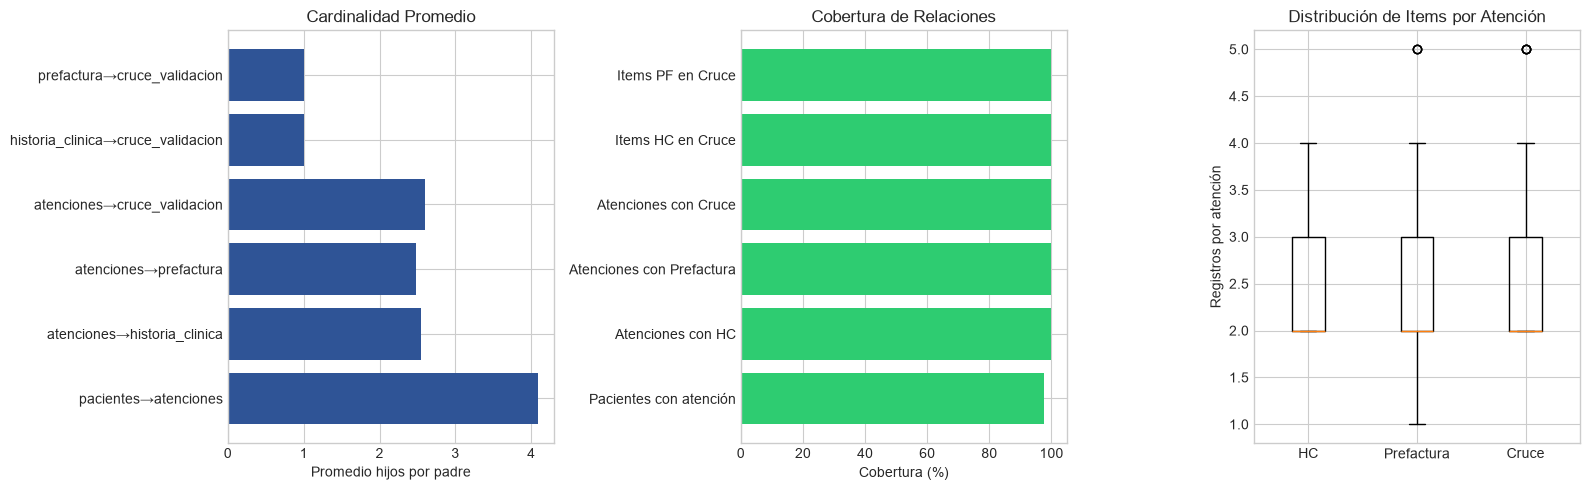

Gráficos guardados en docs/reports/dataset_relationships_charts.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Cardinalidad por relación
ax = axes[0]
rel_names = [f'{r["parent"]}→{r["child"]}' for r in relationships]
avg_children = []
for rel in relationships:
    child_df = datasets_dict[rel['child']]
    fk_col = rel['fk']
    avg = child_df[fk_col].dropna().value_counts().mean()
    avg_children.append(avg)
ax.barh(rel_names, avg_children, color='#2F5496')
ax.set_xlabel('Promedio hijos por padre')
ax.set_title('Cardinalidad Promedio')

# 2. Cobertura de JOINs
ax = axes[1]
cov_names = coverage_df['Relación'].values
cov_values = coverage_df['Cobertura (%)'].values
colors = ['#2ecc71' if v >= 95 else '#f39c12' if v >= 80 else '#e74c3c' for v in cov_values]
ax.barh(cov_names, cov_values, color=colors)
ax.set_xlabel('Cobertura (%)')
ax.set_title('Cobertura de Relaciones')
ax.set_xlim(0, 105)

# 3. Distribución de registros por atención
ax = axes[2]
data_per_at = [
    historia_clinica.groupby('id_atencion').size().values,
    prefactura.groupby('id_atencion').size().values,
    cruce_validacion.groupby('id_atencion').size().values,
]
ax.boxplot(data_per_at, tick_labels=['HC', 'Prefactura', 'Cruce'], vert=True)
ax.set_ylabel('Registros por atención')
ax.set_title('Distribución de Items por Atención')

plt.tight_layout()
plt.savefig('../docs/reports/dataset_relationships_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráficos guardados en docs/reports/dataset_relationships_charts.png')

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Crear figura
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=(
        "Cardinalidad Promedio",
        "Cobertura de Relaciones",
        "Distribución de Items por Atención"
    ),
    specs=[[{"type": "bar"}, {"type": "bar"}, {"type": "box"}]]
)

# ============================================================
# 1. Cardinalidad por relación
# ============================================================
rel_names = [f'{r["parent"]}→{r["child"]}' for r in relationships]

avg_children = []

for rel in relationships:
    child_df = datasets_dict[rel['child']]
    fk_col = rel['fk']
    avg = child_df[fk_col].dropna().value_counts().mean()
    avg_children.append(avg)

fig.add_trace(
    go.Bar(
        x=avg_children,
        y=rel_names,
        orientation='h',
        marker_color='#2F5496',
        text=[f'{v:.2f}' for v in avg_children],
        textposition='outside',
        showlegend=False
    ),
    row=1,
    col=1
)

fig.update_xaxes(title='Promedio hijos por padre', row=1, col=1)

# ============================================================
# 2. Cobertura de JOINs
# ============================================================
cov_names = coverage_df['Relación']
cov_values = coverage_df['Cobertura (%)']

colors = [
    '#2ecc71' if v >= 95 else
    '#f39c12' if v >= 80 else
    '#e74c3c'
    for v in cov_values
]

fig.add_trace(
    go.Bar(
        x=cov_values,
        y=cov_names,
        orientation='h',
        marker_color=colors,
        text=[f'{v:.1f}%' for v in cov_values],
        textposition='outside',
        showlegend=False
    ),
    row=1,
    col=2
)

fig.update_xaxes(
    title='Cobertura (%)',
    range=[0, 105],
    row=1,
    col=2
)

# ============================================================
# 3. Distribución de registros por atención
# ============================================================
data_per_at = {
    'HC': historia_clinica.groupby('id_atencion').size().values,
    'Prefactura': prefactura.groupby('id_atencion').size().values,
    'Cruce': cruce_validacion.groupby('id_atencion').size().values
}

for name, values in data_per_at.items():
    fig.add_trace(
        go.Box(
            y=values,
            name=name,
            boxmean=True,
            showlegend=False
        ),
        row=1,
        col=3
    )

fig.update_yaxes(
    title='Registros por atención',
    row=1,
    col=3
)

# ============================================================
# Diseño
# ============================================================
fig.update_layout(
    title='Relaciones entre Datasets',
    template='plotly_white',
    height=500,
    width=1500,
    margin=dict(t=80, l=50, r=50, b=50)
)

# Mostrar
fig.show()

# Guardar
fig.write_html("../docs/reports/dataset_relationships_charts.html")

# Si tienes kaleido:
# fig.write_image("../docs/reports/dataset_relationships_charts.png", scale=2)

print("Gráficos guardados en docs/reports/dataset_relationships_charts.html")

Gráficos guardados en docs/reports/dataset_relationships_charts.html


---
## 10. Resumen Ejecutivo

### Fortalezas del modelo relacional
- **Integridad referencial perfecta:** Todas las FK apuntan a registros existentes.
- **Cobertura completa de atenciones:** Todas las atenciones tienen HC, prefactura y cruce asociados.
- **Estructura jerárquica clara:** Pacientes → Atenciones → HC/Prefactura → Cruce.
- **Ground truth vinculado:** cruce_validacion conecta directamente con HC y Prefactura.

### Problemas encontrados
- Nulos esperados en cruce_validacion (id_prefactura: 152, id_detalle_hc: 70) por diseño de negocio.
- No se detectaron registros huérfanos ni inconsistencias de integridad.

### Relaciones críticas
1. **atenciones ↔ historia_clinica ↔ prefactura:** Indispensable para BR-01, BR-02, BR-06.
2. **cruce_validacion ↔ todo:** Base del entrenamiento del modelo de IA.
3. **atenciones.diagnostico_principal_cie10 ↔ historia_clinica.codigo_cups:** Para BR-03.

### Recomendaciones para Data Preparation
1. **Usar cruce_validacion como tabla base** del Master Dataset (contiene las etiquetas).
2. **Aplicar LEFT JOIN** para HC y Prefactura (conservar registros con nulos).
3. **Eliminar columnas redundantes** (eps duplicada, id_paciente duplicado, medico_tratante).
4. **Conservar 28 columnas útiles** de las 43 totales.
5. **Tratar nulos** en id_prefactura e id_detalle_hc como indicadores de tipo de alerta.

### Riesgos para Data Preparation
- Los LEFT JOINs generarán columnas con nulos cuando HC o PF no existan.
- Se debe definir estrategia de imputación o encoding para esos nulos.
- La relación N:M implícita entre HC y PF (via atención) debe resolverse correctamente.

### Estrategia de JOIN aprobada
```
cruce_validacion
  INNER JOIN atenciones      ON id_atencion
  LEFT JOIN  pacientes       ON id_paciente
  LEFT JOIN  historia_clinica ON id_detalle_hc = id_detalle
  LEFT JOIN  prefactura      ON id_prefactura
```

---
## Conclusión

Las relaciones entre datasets son **sólidas y completamente funcionales** para construir el Master Dataset.

La estrategia de JOIN definida garantiza:
- Conservar todos los registros del ground truth (cruce_validacion).
- Enriquecer con información clínica y de facturación disponible.
- Manejar correctamente los casos sin HC o sin PF (alertas de tipo específico).

**Siguiente paso:** DU-05 — Realizar Análisis Exploratorio de Datos (EDA).